# PICASO Grid Issues Exploration:

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import h5py

current_directory = Path.cwd()
references_directory_path = "Installation&Setup_Instructions/picasofiles/reference"
PYSYN_directory_path = "Installation&Setup_Instructions/picasofiles/grp/redcat/trds"

os.environ['picaso_refdata']= os.path.join(current_directory, references_directory_path)
os.environ['PYSYN_CDBS']= os.path.join(current_directory, PYSYN_directory_path)

import picaso.justdoit as jdi
import picaso.justplotit as jpi

import copy
import pandas as pd

import numpy as np
from scipy import optimize
from matplotlib import pyplot as plt

import pickle
import astropy.units as u

import Photochem_grid_121625 as Photochem
import GraphsKey as GraphsKey

/gscratch/stf/elizap/envs/subneptune/lib/python3.12/site-packages/picaso/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import declare_namespace


/mmfs1/gscratch/stf/elizap/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference
/mmfs1/gscratch/stf/elizap/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/grp/redcat/trds


## Load PICASO Files:

In [16]:
filename = 'results/PICASO_climate_updatop_full_exploration_reducedrad_solveSegFault.h5'
rad = 2
metal = 3.5
tint = 250
semi_major = 10
ctoO = 0.01
PT_list, convergence_values, status_message, error_message = Photochem.find_PT_grid(filename=filename, rad_plan=rad, log10_planet_metallicity=metal, tint=tint, semi_major=semi_major, ctoO=ctoO)

This is the input list: [2.0e+00 3.5e+00 2.5e+02 1.0e+01 1.0e-02]
PICASO did not converge or has an error: status=error, error=Z


Make sure your inputs are within the following ranges, rad_plan: 2 - 2 xEarth Radii, planet metallicity: 0.5 - 3.5 xsolar, tint: 50.0 - 400.0 K, semi_major: 0.3 - 10.0 AU, ctoO: 0.01 - 1.0
This is the input list: [2.0e+00 3.5e+00 2.5e+02 3.0e-01 1.0e-02]
Was able to successfully find your input parameters in the PICASO TP profile grid!
All inputs chosen were directly on the grid!
Does not include Photochemistry extension of PT profile


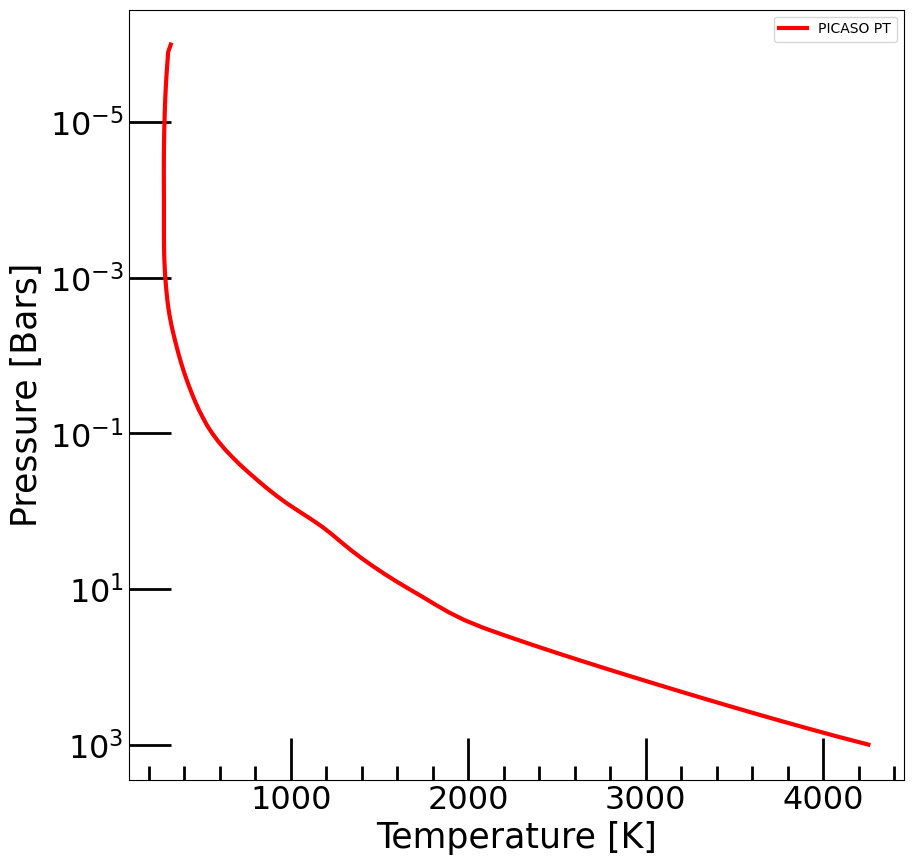

In [13]:
GraphsKey.plot_PT(rad_plan=rad, planet_metal=metal, tint=tint, semi_major=semi_major, ctoO=ctoO, kzz=None, calc_PT=True, calc_PhotCh=False, PT_filepath=filename)

In [30]:
filename_picaso ='results/PICASO_climate_updatop_full_exploration_reducedrad.h5'
target_list = [rad, metal, tint, semi_major, ctoO] 
# Index: 0, 8, 0, 0, 0

with h5py.File(filename_picaso, 'r') as f:
    picaso_data = f
    picaso_inputs = list(picaso_data['inputs'])
    #print(list(picaso_data['inputs']))
    
    indices = [i for i, arr in enumerate(picaso_inputs) if np.array_equal(arr, target_list)]
    print(indices)

    print(list(picaso_data['results']['error'][0][8][1][8][0]))

[3625]
[b'Z']


In [2]:
 # Full Parameter Exploration
rad_plan_earth_units = np.array([2]) # in units of xEarth radii
log10_planet_metallicity = np.linspace(0.5, 3.5, 9) # in units of solar metallicity
tint_K = np.linspace(50, 400, 8) # in Kelvin
semi_major_AU = np.array([0.3, 0.7, 1, 1.5, 2, 3, 4, 5, 6, 8, 10]) # in AU 
ctoO_solar = np.linspace(0.01, 1, 5) # in units of solar C/O

## Look at Errors Recorded for specific PICASO file

In [73]:
filename_picaso ='results/PICASO_climate_updatop_full_exploration_reducedrad.h5'

with h5py.File(filename_picaso, 'r') as f:
    picaso_data = f
    print(list(picaso_data.keys()))
    #print(list(picaso_data['inputs']))
    print(list(picaso_data['results'].keys()))
    print(list(picaso_data['results']['status'][0][0][0][0]))
    #print(list(picaso_data['completed']))
    #print(list(picaso_data['inputs']))
    #print(list(picaso_data['inputs'][0]))

    pressure = f['results']['pressure']
    temperature = f['results']['temperature']
    converged = f['results']['converged']

    # Get grid sizes
    Nr, Nm, Nt, Na, Nc = pressure.shape[:5]

    for i in range(Nr):
        for j in range(Nm):
            for k in range(Nt):
                for l in range(Na):
                    for m in range(Nc):

                        pressure_values = np.array(pressure[i, j, k, l, m])
                        temperature_values = np.array(temperature[i, j, k, l, m])
                        conv_value = np.array(converged[i, j, k, l, m])

                        # Do something with them
                        print(i, j, k, l, m, conv_value)

['completed', 'inputs', 'results']
['converged', 'error', 'pressure', 'status', 'temperature']
[array([b'converged'], dtype='|S9'), array([b'converged'], dtype='|S9'), array([b'converged'], dtype='|S9'), array([b'converged'], dtype='|S9'), array([b'converged'], dtype='|S9')]
0 0 0 0 0 [1]
0 0 0 0 1 [1]
0 0 0 0 2 [1]
0 0 0 0 3 [1]
0 0 0 0 4 [1]
0 0 0 1 0 [1]
0 0 0 1 1 [1]
0 0 0 1 2 [1]
0 0 0 1 3 [1]
0 0 0 1 4 [1]
0 0 0 2 0 [1]
0 0 0 2 1 [1]
0 0 0 2 2 [1]
0 0 0 2 3 [1]
0 0 0 2 4 [1]
0 0 0 3 0 [1]
0 0 0 3 1 [1]
0 0 0 3 2 [1]
0 0 0 3 3 [1]
0 0 0 3 4 [1]
0 0 0 4 0 [1]
0 0 0 4 1 [1]
0 0 0 4 2 [1]
0 0 0 4 3 [1]
0 0 0 4 4 [1]
0 0 0 5 0 [1]
0 0 0 5 1 [1]
0 0 0 5 2 [1]
0 0 0 5 3 [1]
0 0 0 5 4 [1]
0 0 0 6 0 [1]
0 0 0 6 1 [1]
0 0 0 6 2 [1]
0 0 0 6 3 [1]
0 0 0 6 4 [1]
0 0 0 7 0 [1]
0 0 0 7 1 [1]
0 0 0 7 2 [1]
0 0 0 7 3 [1]
0 0 0 7 4 [1]
0 0 0 8 0 [1]
0 0 0 8 1 [1]
0 0 0 8 2 [1]
0 0 0 8 3 [1]
0 0 0 8 4 [1]
0 0 0 9 0 [1]
0 0 0 9 1 [1]
0 0 0 9 2 [1]
0 0 0 9 3 [1]
0 0 0 9 4 [1]
0 0 0 10 0 [1]
0 0 0 10 

In [74]:
import numpy as np
import h5py

# --- Build grid dictionary ---
rad_plan_earth_units = np.array([2])
log10_planet_metallicity = np.linspace(0.5, 3.5, 9)
tint_K = np.linspace(50, 400, 8)
semi_major_AU = np.array([0.3, 0.7, 1, 1.5, 2, 3, 4, 5, 6, 8, 10])
ctoO_solar = np.linspace(0.01, 1, 5)

gridvals_dict = {
    'planet_radius': rad_plan_earth_units,
    'planet_metallicity': log10_planet_metallicity,
    'tint': tint_K,
    'semi_major': semi_major_AU,
    'ctoO': ctoO_solar
}

filename_picaso ='results/PICASO_climate_updatop_full_exploration_reducedrad.h5'

with h5py.File(filename_picaso, 'r') as f:

    status = np.array(f['results']['status'])

    print("Status grid shape:", status.shape)

    # handle byte strings
    if status.dtype.kind == 'S':
        error_locs = np.argwhere(status == b'error')
    else:
        error_locs = np.argwhere(status == 'error')

    radii = gridvals_dict['planet_radius']
    metals = gridvals_dict['planet_metallicity']
    tints = gridvals_dict['tint']
    semis = gridvals_dict['semi_major']
    ctos = gridvals_dict['ctoO']

    error_models = []

    for idx in error_locs:

        # only take first 5 indices (grid dimensions)
        r_i, m_i, t_i, a_i, c_i = idx[:5]

        params = {
            "planet_radius": radii[r_i],
            "planet_metallicity": metals[m_i],
            "tint": tints[t_i],
            "semi_major": semis[a_i],
            "ctoO": ctos[c_i]
        }

        error_models.append(params)

        print(
            f"Error at: "
            f"R={params['planet_radius']}, "
            f"Z={params['planet_metallicity']}, "
            f"Tint={params['tint']}, "
            f"a={params['semi_major']}, "
            f"C/O={params['ctoO']}"
        )

    print("\nTotal error models:", len(error_models))

Status grid shape: (1, 9, 8, 11, 5, 1)
Error at: R=2, Z=2.75, Tint=200.0, a=8.0, C/O=0.7525
Error at: R=2, Z=2.75, Tint=250.0, a=6.0, C/O=0.01
Error at: R=2, Z=2.75, Tint=250.0, a=10.0, C/O=0.505
Error at: R=2, Z=2.75, Tint=250.0, a=10.0, C/O=1.0
Error at: R=2, Z=2.75, Tint=300.0, a=10.0, C/O=0.7525
Error at: R=2, Z=2.75, Tint=400.0, a=10.0, C/O=0.7525
Error at: R=2, Z=3.125, Tint=50.0, a=1.0, C/O=0.01
Error at: R=2, Z=3.125, Tint=50.0, a=1.0, C/O=0.2575
Error at: R=2, Z=3.125, Tint=50.0, a=1.5, C/O=0.01
Error at: R=2, Z=3.125, Tint=50.0, a=1.5, C/O=0.2575
Error at: R=2, Z=3.125, Tint=50.0, a=2.0, C/O=0.01
Error at: R=2, Z=3.125, Tint=50.0, a=2.0, C/O=0.2575
Error at: R=2, Z=3.125, Tint=50.0, a=3.0, C/O=0.01
Error at: R=2, Z=3.125, Tint=50.0, a=3.0, C/O=0.2575
Error at: R=2, Z=3.125, Tint=50.0, a=4.0, C/O=0.2575
Error at: R=2, Z=3.125, Tint=50.0, a=8.0, C/O=0.505
Error at: R=2, Z=3.125, Tint=100.0, a=1.0, C/O=0.01
Error at: R=2, Z=3.125, Tint=100.0, a=1.0, C/O=0.2575
Error at: R=2, Z=3

In [75]:
import numpy as np
import h5py

filename_picaso = 'results/PICASO_climate_updatop_full_exploration_reducedrad.h5'

# Original grid definitions
rad_plan_earth_units = np.array([2])
log10_planet_metallicity = np.linspace(0.5, 3.5, 9)
tint_K = np.linspace(50, 400, 8)
semi_major_AU = np.array([0.3, 0.7, 1, 1.5, 2, 3, 4, 5, 6, 8, 10])
ctoO_solar = np.linspace(0.01, 1, 5)

# Storage containers
error_indices_list = []
crash_indices_list = []
error_parameter_values = []
crash_parameter_values = []

with h5py.File(filename_picaso, 'r') as f:

    status = np.array(f['results']['status'])

    print("Status shape:", status.shape)

    # Locate errors
    if status.dtype.kind == 'S':
        error_locs = np.argwhere(status == b'error')
    else:
        error_locs = np.argwhere(status == 'error')

    for idx in error_locs:

        # First 5 indices correspond to the input grid
        r_i, m_i, t_i, a_i, c_i = idx[:5]

        # Save indices
        error_indices = {
            "radius_idx": r_i,
            "metallicity_idx": m_i,
            "tint_idx": t_i,
            "semi_major_idx": a_i,
            "ctoO_idx": c_i
        }

        # Map indices to physical parameter values
        error_params = {
            "radius": rad_plan_earth_units[r_i],
            "metallicity": log10_planet_metallicity[m_i],
            "tint": tint_K[t_i],
            "semi_major": semi_major_AU[a_i],
            "ctoO": ctoO_solar[c_i]
        }

        # Store results
        error_indices_list.append(error_indices)
        error_parameter_values.append(error_params)

        # Print diagnostic
        print("\nGRID INDICES:", error_indices)
        print("PARAMETERS:", error_params)

print("\nTotal error models found:", len(error_indices_list))

Status shape: (1, 9, 8, 11, 5, 1)

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 6, 'tint_idx': 3, 'semi_major_idx': 9, 'ctoO_idx': 3}
PARAMETERS: {'radius': 2, 'metallicity': 2.75, 'tint': 200.0, 'semi_major': 8.0, 'ctoO': 0.7525}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 6, 'tint_idx': 4, 'semi_major_idx': 8, 'ctoO_idx': 0}
PARAMETERS: {'radius': 2, 'metallicity': 2.75, 'tint': 250.0, 'semi_major': 6.0, 'ctoO': 0.01}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 6, 'tint_idx': 4, 'semi_major_idx': 10, 'ctoO_idx': 2}
PARAMETERS: {'radius': 2, 'metallicity': 2.75, 'tint': 250.0, 'semi_major': 10.0, 'ctoO': 0.505}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 6, 'tint_idx': 4, 'semi_major_idx': 10, 'ctoO_idx': 4}
PARAMETERS: {'radius': 2, 'metallicity': 2.75, 'tint': 250.0, 'semi_major': 10.0, 'ctoO': 1.0}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 6, 'tint_idx': 5, 'semi_major_idx': 10, 'ctoO_idx': 3}
PARAMETERS: {'radius': 2, 'metallicity': 2.75, 't

In [76]:
error_statements_list = []
status_statements_list = []

with h5py.File(filename_picaso, 'r') as f:

    error = f['results']['error']
    print(list(error))
    status = f['results']['status']
    #print(f['results']['error'][0][7][4][7][1])
    #print(list(error[0][6][5][10][3][0]))

    for idx in error_indices_list:

        r = idx["radius_idx"]
        m = idx["metallicity_idx"]
        t = idx["tint_idx"]
        a = idx["semi_major_idx"]
        c = idx["ctoO_idx"]

        # Option 1: Join the byte chars back together
        error_message = error[r, m, t, a, c]
        error_statements_list.append(error_message)
        
        # Same for status
        status_message = status[r, m, t, a, c]
        status_statements_list.append(status_message)

[array([[[[[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         ...,

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']]],


        [[[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         ...,

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [

In [77]:
error_statements_list

[array([b'V'], dtype='|S1'),
 array([b'V'], dtype='|S1'),
 array([b'V'], dtype='|S1'),
 array([b'V'], dtype='|S1'),
 array([b'V'], dtype='|S1'),
 array([b'V'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'V'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'], dtype='|S1'),
 array([b'Z'],

In [78]:
status_statements_list

[array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'error'], dtype='|S9'),
 array([b'

In [79]:
import numpy as np
import h5py

filename_picaso = 'results/PICASO_climate_updatop_full_exploration_reducedrad.h5'

# Original grid definitions
rad_plan_earth_units = np.array([2])
log10_planet_metallicity = np.linspace(0.5, 3.5, 9)
tint_K = np.linspace(50, 400, 8)
semi_major_AU = np.array([0.3, 0.7, 1, 1.5, 2, 3, 4, 5, 6, 8, 10])
ctoO_solar = np.linspace(0.01, 1, 5)

# Containers to store results
notconv_indices_list = []
notconv_parameter_values = []

with h5py.File(filename_picaso, 'r') as f:

    status = np.array(f['results']['status'])
    print("Status shape:", status.shape)

    # Find "not_converged" entries
    if status.dtype.kind == 'S':
        notconv_locs = np.argwhere(status == b'converged')
    else:
        notconv_locs = np.argwhere(status == 'converged')

    for idx in notconv_locs:

        # first 5 indices correspond to input grid
        r_i, m_i, t_i, a_i, c_i = idx[:5]

        indices = {
            "radius_idx": r_i,
            "metallicity_idx": m_i,
            "tint_idx": t_i,
            "semi_major_idx": a_i,
            "ctoO_idx": c_i
        }

        params = {
            "radius": rad_plan_earth_units[r_i],
            "metallicity": log10_planet_metallicity[m_i],
            "tint": tint_K[t_i],
            "semi_major": semi_major_AU[a_i],
            "ctoO": ctoO_solar[c_i]
        }

        notconv_indices_list.append(indices)
        notconv_parameter_values.append(params)

        print("\nGRID INDICES:", indices)
        print("PARAMETERS:", params)

print("\nTotal converged models:", len(notconv_indices_list))

Status shape: (1, 9, 8, 11, 5, 1)

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 0, 'tint_idx': 0, 'semi_major_idx': 0, 'ctoO_idx': 0}
PARAMETERS: {'radius': 2, 'metallicity': 0.5, 'tint': 50.0, 'semi_major': 0.3, 'ctoO': 0.01}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 0, 'tint_idx': 0, 'semi_major_idx': 0, 'ctoO_idx': 1}
PARAMETERS: {'radius': 2, 'metallicity': 0.5, 'tint': 50.0, 'semi_major': 0.3, 'ctoO': 0.2575}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 0, 'tint_idx': 0, 'semi_major_idx': 0, 'ctoO_idx': 2}
PARAMETERS: {'radius': 2, 'metallicity': 0.5, 'tint': 50.0, 'semi_major': 0.3, 'ctoO': 0.505}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 0, 'tint_idx': 0, 'semi_major_idx': 0, 'ctoO_idx': 3}
PARAMETERS: {'radius': 2, 'metallicity': 0.5, 'tint': 50.0, 'semi_major': 0.3, 'ctoO': 0.7525}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 0, 'tint_idx': 0, 'semi_major_idx': 0, 'ctoO_idx': 4}
PARAMETERS: {'radius': 2, 'metallicity': 0.5, 'tint': 50.0,

#### Looking for specific cases that were Segmentation Faults

In [87]:
with h5py.File(filename_picaso, 'r') as f:

    status = np.array(f['results']['status'][0][8][1][7][0])
    error = np.array(f['results']['error'][0][8][1][7][0])
    converged = np.array(f['results']['converged'][0][8][1][7][0])
    print(list(f['results'].keys()))
    print(status)
    print(error)
    print(converged)

['converged', 'error', 'pressure', 'status', 'temperature']
[b'crash']
[b'P']
[0]


In [101]:
crash_indices_list = []
crash_parameter_values = []
crash_parameter_list = []

with h5py.File(filename_picaso, 'r') as f:

    status = np.array(f['results']['status'])

    print("Status shape:", status.shape)

    # Locate errors
    if status.dtype.kind == 'S':
        crash_locs = np.argwhere(status == b'crash')
    else:
        crash_locs = np.argwhere(status == 'crash')

    for idx in crash_locs:

        # First 5 indices correspond to the input grid
        r_i, m_i, t_i, a_i, c_i = idx[:5]

        # Save indices
        crash_indices = {
            "radius_idx": r_i,
            "metallicity_idx": m_i,
            "tint_idx": t_i,
            "semi_major_idx": a_i,
            "ctoO_idx": c_i
        }

        # Map indices to physical parameter values
        crash_params = {
            "radius": rad_plan_earth_units[r_i],
            "metallicity": log10_planet_metallicity[m_i],
            "tint": tint_K[t_i],
            "semi_major": semi_major_AU[a_i],
            "ctoO": ctoO_solar[c_i]
        }

        # Store results
        crash_indices_list.append(crash_indices)
        crash_parameter_values.append(crash_params)
        crash_parameter_list.append([rad_plan_earth_units[r_i], log10_planet_metallicity[m_i], tint_K[t_i], semi_major_AU[a_i], ctoO_solar[c_i]])

        # Print diagnostic
        print("\nGRID INDICES:", crash_indices)
        print("PARAMETERS:", crash_params)

print("\nTotal crash models found:", len(crash_indices_list))

Status shape: (1, 9, 8, 11, 5, 1)

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 8, 'tint_idx': 0, 'semi_major_idx': 2, 'ctoO_idx': 1}
PARAMETERS: {'radius': 2, 'metallicity': 3.5, 'tint': 50.0, 'semi_major': 1.0, 'ctoO': 0.2575}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 8, 'tint_idx': 1, 'semi_major_idx': 7, 'ctoO_idx': 0}
PARAMETERS: {'radius': 2, 'metallicity': 3.5, 'tint': 100.0, 'semi_major': 5.0, 'ctoO': 0.01}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 8, 'tint_idx': 1, 'semi_major_idx': 8, 'ctoO_idx': 1}
PARAMETERS: {'radius': 2, 'metallicity': 3.5, 'tint': 100.0, 'semi_major': 6.0, 'ctoO': 0.2575}

GRID INDICES: {'radius_idx': 0, 'metallicity_idx': 8, 'tint_idx': 1, 'semi_major_idx': 8, 'ctoO_idx': 2}
PARAMETERS: {'radius': 2, 'metallicity': 3.5, 'tint': 100.0, 'semi_major': 6.0, 'ctoO': 0.505}

Total crash models found: 4


In [103]:
print(crash_parameter_list)

[[2, 3.5, 50.0, 1.0, 0.2575], [2, 3.5, 100.0, 5.0, 0.01], [2, 3.5, 100.0, 6.0, 0.2575], [2, 3.5, 100.0, 6.0, 0.505]]


In [91]:
crash_statements_list = []
crash_status_statements_list = []

with h5py.File(filename_picaso, 'r') as f:

    error = f['results']['error']
    print(list(error))
    status = f['results']['status']
    #print(f['results']['error'][0][7][4][7][1])
    #print(list(error[0][6][5][10][3][0]))

    for idx in crash_indices_list:

        r = idx["radius_idx"]
        m = idx["metallicity_idx"]
        t = idx["tint_idx"]
        a = idx["semi_major_idx"]
        c = idx["ctoO_idx"]

        # Option 1: Join the byte chars back together
        error_message = error[r, m, t, a, c]
        crash_statements_list.append(error_message)
        
        # Same for status
        status_message = status[r, m, t, a, c]
        crash_status_statements_list.append(status_message)

[array([[[[[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         ...,

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']]],


        [[[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         ...,

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [[b''],
          [b''],
          [b''],
          [b''],
          [b'']],

         [

In [92]:
crash_statements_list

[array([b'P'], dtype='|S1'),
 array([b'P'], dtype='|S1'),
 array([b'P'], dtype='|S1'),
 array([b'P'], dtype='|S1')]

In [93]:
crash_status_statements_list

[array([b'crash'], dtype='|S9'),
 array([b'crash'], dtype='|S9'),
 array([b'crash'], dtype='|S9'),
 array([b'crash'], dtype='|S9')]

#### What does these error statements refer to?
- 'Z' refers to 'ZeroDivisionError: division by zero error'
- 'V' refers to 'ValueError: Convection zone grew to Top of atmosphere, Need to Stop'
- 'P' refers to 'Fatal Python error: Segmentation fault'
- There was also an error with 'NameError: name '_record_failure' is not defined' due to error in script, which might be why the processes were crashing? Granted not sure where this came into play, but will see if it gets fixed.
  

## Check what inputs have not run yet

In [80]:
# Full Parameter Exploration
rad_plan_earth_units = np.array([2]) # in units of xEarth radii
log10_planet_metallicity = np.linspace(0.5, 3.5, 9) # in units of solar metallicity
tint_K = np.linspace(50, 400, 8) # in Kelvin
semi_major_AU = np.array([0.3, 0.7, 1, 1.5, 2, 3, 4, 5, 6, 8, 10]) # in AU 
ctoO_solar = np.linspace(0.01, 1, 5) # in units of solar C/O

gridvals = (rad_plan_earth_units, log10_planet_metallicity, tint_K, semi_major_AU, ctoO_solar, log10_planet_metallicity)

# Need to make the combination list to pick from:
combination_list = []

for rad in rad_plan_earth_units:
    for metal in log10_planet_metallicity:
        for tint in tint_K:
            for semi_major in semi_major_AU:
                for ctoO in ctoO_solar:
                    input_list = [rad, metal, tint, semi_major, ctoO]
                    combination_list.append(input_list)
                    
print(len(combination_list))

3960


In [81]:
import numpy as np
import h5py

def loop_check_inputs(filename=None, combination_inputs=None, atol=1e-10):
    """
    Return all input combinations that are NOT present in f['inputs'].
    """
    if filename is None or combination_inputs is None:
        return []

    inputs_not_run_yet = []

    with h5py.File(filename, 'r') as f:
        ran_inputs = np.array(f['inputs'], dtype=float)  # shape: (N, 5)

    for case in combination_inputs:
        case_arr = np.array(case, dtype=float)  # [rad, metal, tint, semi_major, ctoO]
        row_matches = np.all(np.isclose(ran_inputs, case_arr[None, :], atol=atol, rtol=0), axis=1)

        if not np.any(row_matches):
            inputs_not_run_yet.append(case)

    return inputs_not_run_yet

In [104]:
inputs_not_run_yet = loop_check_inputs(
    filename=filename_picaso,
    combination_inputs=combination_list
)

print("Missing count:", len(inputs_not_run_yet))
print(len(inputs_not_run_yet))  # preview

Missing count: 395
395


In [105]:
inputs_not_run_yet_added_segfault = inputs_not_run_yet.copy()

for parameter_list in crash_parameter_list: 
    inputs_not_run_yet_added_segfault.append(parameter_list)


In [114]:
print(len(inputs_not_run_yet_added_segfault))

399


In [116]:
import os
import numpy as np

# Source list from your notebook
data = inputs_not_run_yet_added_segfault

# ---- 1) Validate + normalize to float array (N,5) ----
arr = np.asarray(data, dtype=float)
if arr.ndim != 2 or arr.shape[1] != 5:
    raise ValueError(f"Expected shape (N,5), got {arr.shape}")

# ---- 2) Remove duplicates while preserving first occurrence order ----
seen = set()
unique_rows = []
for row in arr:
    key = tuple(np.round(row, 10))  # robust float key
    if key not in seen:
        seen.add(key)
        unique_rows.append(row)

unique_arr = np.asarray(unique_rows, dtype=float)

# Optional: sort for reproducibility (metal, tint, semi-major, ctoO)
sort_idx = np.lexsort((
    unique_arr[:, 4],  # ctoO
    unique_arr[:, 3],  # semi-major
    unique_arr[:, 2],  # tint
    unique_arr[:, 1],  # metallicity
    unique_arr[:, 0],  # radius
))
unique_arr = unique_arr[sort_idx]

# ---- 3) Split into two batches ----
N = len(unique_arr)
mid = N // 2
batchA = unique_arr[:mid]
batchB = unique_arr[mid:]

# ---- 4) Save ----
os.makedirs("results", exist_ok=True)
np.save("missing_batchA.npy", batchA)
np.save("missing_batchB.npy", batchB)

# ---- 5) Report structure ----
print("Final unique missing cases:", N)
print("Batch A shape:", batchA.shape, "-> missing_batchA.npy")
print("Batch B shape:", batchB.shape, "-> missing_batchB.npy")
print("Row format: [rad, metallicity, tint, semi_major_AU, ctoO]")

# Quick check reload
A = np.load("missing_batchA.npy")
B = np.load("missing_batchB.npy")
print("Reload check:", A.shape, B.shape)

Final unique missing cases: 399
Batch A shape: (199, 5) -> missing_batchA.npy
Batch B shape: (200, 5) -> missing_batchB.npy
Row format: [rad, metallicity, tint, semi_major_AU, ctoO]
Reload check: (199, 5) (200, 5)
[[2.000e+00 2.750e+00 1.000e+02 1.000e+01 7.525e-01]
 [2.000e+00 2.750e+00 2.000e+02 1.000e+01 1.000e-02]
 [2.000e+00 2.750e+00 3.500e+02 1.000e+01 1.000e-02]
 [2.000e+00 3.125e+00 2.000e+02 3.000e+00 2.575e-01]
 [2.000e+00 3.125e+00 2.000e+02 6.000e+00 5.050e-01]
 [2.000e+00 3.125e+00 2.000e+02 6.000e+00 7.525e-01]
 [2.000e+00 3.125e+00 2.000e+02 6.000e+00 1.000e+00]
 [2.000e+00 3.125e+00 2.000e+02 8.000e+00 5.050e-01]
 [2.000e+00 3.125e+00 2.000e+02 1.000e+01 1.000e+00]
 [2.000e+00 3.125e+00 2.500e+02 3.000e+00 7.525e-01]
 [2.000e+00 3.125e+00 2.500e+02 3.000e+00 1.000e+00]
 [2.000e+00 3.125e+00 2.500e+02 4.000e+00 5.050e-01]
 [2.000e+00 3.125e+00 2.500e+02 4.000e+00 7.525e-01]
 [2.000e+00 3.125e+00 2.500e+02 4.000e+00 1.000e+00]
 [2.000e+00 3.125e+00 2.500e+02 5.000e+00 5.

In [113]:
# Just checking that there are no repeated indices:

from collections import Counter

# paste your 2D list into `data`
data = inputs_not_run_yet_added_segfault  # ...existing code...

# normalize each row to a tuple for hashing
rows = [tuple(map(float, row)) for row in data]
counts = Counter(rows)

dupes = [(row, n) for row, n in counts.items() if n > 1]

print(f"Total rows: {len(rows)}")
print(f"Unique rows: {len(counts)}")
print(f"Duplicate patterns: {len(dupes)}")

for row, n in sorted(dupes, key=lambda x: (-x[1], x[0])):
    print(f"{row} -> {n} times")

Total rows: 399
Unique rows: 399
Duplicate patterns: 0


### Looking for a good list of what values to run:
- Easiest way to run the cases that have yet to run is to just loop through the inputs in the missing inputs list and arguably 